In [ ]:
import pandas as pd
import numpy as np

ANNOTATION_PATH = "/content/filled_data.xlsx"

ann = pd.read_excel(ANNOTATION_PATH)

required_cols = [
    "AnnotationID",
    "StableID",
    "llm1_label",
    "llm1_score",
    "llm1_confidence"
]

missing_cols = [c for c in required_cols if c not in ann.columns]
ann_labeled = ann.dropna(subset=["llm1_label"]).copy()

ann_labeled["final_label"] = pd.to_numeric(
    ann_labeled["llm1_label"],
    errors="coerce"
)

ann_labeled["final_label"] = ann_labeled["final_label"].astype(int)
ann_labeled["final_score"] = ann_labeled["llm1_score"]
ann_labeled["final_confidence"] = ann_labeled["llm1_confidence"]


In [ ]:
import pickle
import os

TRAINING_DATA_PATH = "/content/windows_training_data_30min_v3.pkl"

with open(TRAINING_DATA_PATH, "rb") as f:
    data = pickle.load(f)

print(data.keys())

train_normal = data["train_normal"].copy()
annotation_df = data["annotation_df"].copy()

print("train_normal:", train_normal.shape)
print("annotation_df:", annotation_df.shape)

ann_labeled["AnnotationID"] = ann_labeled["AnnotationID"].astype(int)
annotation_df["AnnotationID"] = annotation_df["AnnotationID"].astype(int)

label_cols = [
    "AnnotationID",
    "StableID",
    "final_label",
    "final_score",
    "final_confidence",
    "llm1_label",
    "llm1_score",
    "llm1_confidence",
    "llm1_key_events",
    "llm1_reason"
]

label_cols = [c for c in label_cols if c in ann_labeled.columns]

ann_labels = ann_labeled[label_cols].copy()

annotation_labeled = annotation_df.merge(
    ann_labels,
    on=["AnnotationID", "StableID"],
    how="inner"
)

print("annotation_labeled:", annotation_labeled.shape)
print("ann_labeled rows:", len(ann_labeled))
print("merged rows:", len(annotation_labeled))

if len(annotation_labeled) != len(ann_labeled):
    missing = ann_labeled.merge(
        annotation_df[["AnnotationID", "StableID"]],
        on=["AnnotationID", "StableID"],
        how="left",
        indicator=True
    )

    print("Не смержилось строк:", (missing["_merge"] == "left_only").sum())
    display(missing[missing["_merge"] == "left_only"].head(20))

    raise ValueError("Не все размеченные строки смержились")

dict_keys(['params', 'train_normal', 'val_seq', 'test_seq', 'annotation_df', 'template_to_id', 'id_to_template'])
train_normal: (2697, 31)
annotation_df: (1698, 33)
annotation_labeled: (1698, 41)
ann_labeled rows: 1698
merged rows: 1698


In [ ]:
val_seq_labeled = annotation_labeled[
    annotation_labeled["Split"] == "val"
].copy()

test_seq_labeled = annotation_labeled[
    annotation_labeled["Split"] == "test"
].copy()

print("val_seq_labeled:", val_seq_labeled.shape)
print("test_seq_labeled:", test_seq_labeled.shape)

print("\nVal label distribution:")
print(val_seq_labeled["final_label"].value_counts())
print(val_seq_labeled["final_label"].value_counts(normalize=True))

print("\nTest label distribution:")
print(test_seq_labeled["final_label"].value_counts())
print(test_seq_labeled["final_label"].value_counts(normalize=True))

SAVE_DIR = "/content/drive/MyDrive/windows_logs_project/export_30min_v3"
os.makedirs(SAVE_DIR, exist_ok=True)

LABELED_DATA_PATH = f"{SAVE_DIR}/windows_training_data_labeled_30min_v3.pkl"

labeled_data = {
    "params": {
        **data["params"],
        "ANNOTATION_SOURCE": "single_llm_llm1",
        "VAL_TEST_MIXED": False,
        "NOTE": (
            "train_normal unchanged; validation and test splits preserved; "
            "labels are obtained from llm1 annotation"
        )
    },
    "train_normal": train_normal,
    "val_seq": val_seq_labeled,
    "test_seq": test_seq_labeled,
    "annotation_df": annotation_labeled,
    "template_to_id": data["template_to_id"],
    "id_to_template": data["id_to_template"]
}

with open(LABELED_DATA_PATH, "wb") as f:
    pickle.dump(labeled_data, f)

print("Saved:", LABELED_DATA_PATH)

val_seq_labeled: (775, 41)
test_seq_labeled: (923, 41)

Val label distribution:
final_label
0    451
1    324
Name: count, dtype: int64
final_label
0    0.581935
1    0.418065
Name: proportion, dtype: float64

Test label distribution:
final_label
1    514
0    409
Name: count, dtype: int64
final_label
1    0.55688
0    0.44312
Name: proportion, dtype: float64
Saved: /content/drive/MyDrive/windows_logs_project/export_30min_v3/windows_training_data_labeled_30min_v3.pkl


In [ ]:
import pickle
import os
import math
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

LABELED_DATA_PATH = "/content/drive/MyDrive/windows_logs_project/export_30min_v3/windows_training_data_labeled_30min_v3.pkl"

with open(LABELED_DATA_PATH, "rb") as f:
    labeled_data = pickle.load(f)

train_normal = labeled_data["train_normal"].copy()
val_seq = labeled_data["val_seq"].copy()
test_seq = labeled_data["test_seq"].copy()

print("train_normal:", train_normal.shape)
print("val_seq:", val_seq.shape)
print("test_seq:", test_seq.shape)

Device: cuda
train_normal: (2697, 31)
val_seq: (775, 41)
test_seq: (923, 41)


In [ ]:
import hashlib

PAD_TOKEN = "<PAD>"

NUM_UNK_BUCKETS = 64
PAD_IDX = 0
UNK_OFFSET = 1

token_to_idx = {
    PAD_TOKEN: PAD_IDX
}

for i in range(NUM_UNK_BUCKETS):
    token_to_idx[f"<UNK_{i}>"] = UNK_OFFSET + i

for df_name, df in [
    ("train_normal", train_normal),
    ("val_seq", val_seq),
    ("test_seq", test_seq)
]:
    if "Features" not in df.columns:
        raise ValueError(f"В {df_name} нет колонки Features")

train_tokens = sorted({
    token
    for seq in train_normal["Features"]
    for token in seq
})

for token in train_tokens:
    if token not in token_to_idx:
        token_to_idx[token] = len(token_to_idx)

idx_to_token = {v: k for k, v in token_to_idx.items()}
VOCAB_SIZE = len(token_to_idx)

print("VOCAB_SIZE:", VOCAB_SIZE)
print("PAD_IDX:", PAD_IDX)
print("UNK_BUCKETS:", NUM_UNK_BUCKETS)
print("UNK range:", UNK_OFFSET, "to", UNK_OFFSET + NUM_UNK_BUCKETS - 1)


def stable_hash_bucket(token, num_buckets=NUM_UNK_BUCKETS):
    h = hashlib.md5(str(token).encode("utf-8")).hexdigest()
    return int(h, 16) % num_buckets


def encode_token(token):
    if token in token_to_idx:
        return token_to_idx[token]

    bucket = stable_hash_bucket(token)
    return UNK_OFFSET + bucket


def encode_sequence(seq):
    return [encode_token(token) for token in seq]


def is_unk_id(x):
    return UNK_OFFSET <= x < UNK_OFFSET + NUM_UNK_BUCKETS


def count_unk_ids(seq):
    return sum(is_unk_id(x) for x in seq)


train_normal["EncodedFeatures"] = train_normal["Features"].apply(encode_sequence)
val_seq["EncodedFeatures"] = val_seq["Features"].apply(encode_sequence)
test_seq["EncodedFeatures"] = test_seq["Features"].apply(encode_sequence)

VOCAB_SIZE: 804
PAD_IDX: 0
UNK_BUCKETS: 64
UNK range: 1 to 64


In [ ]:
MAX_LEN = 64

best_config = {
    "run_name": "dropout_01_windows",
    "d_model": 128,
    "nhead": 4,
    "num_layers": 2,
    "dim_feedforward": 256,
    "dropout": 0.1,
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "max_len": MAX_LEN,
    "num_epochs": 7,
    "patience": 3,
    "max_grad_norm": 1.0,
    "batch_size": 256
}


class NextEventDataset(Dataset):
    def __init__(self, sequences, max_len=64, pad_idx=0):
        self.samples = []
        self.max_len = max_len
        self.pad_idx = pad_idx

        for seq in sequences:
            if len(seq) < 2:
                continue

            for i in range(1, len(seq)):
                prefix = seq[:i]
                target = seq[i]

                if len(prefix) > max_len:
                    prefix = prefix[-max_len:]

                self.samples.append((prefix, target))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        prefix, target = self.samples[idx]

        length = len(prefix)

        padded = prefix + [self.pad_idx] * (self.max_len - length)
        attention_mask = [1] * length + [0] * (self.max_len - length)

        return {
            "input_ids": torch.tensor(padded, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "target": torch.tensor(target, dtype=torch.long),
            "length": torch.tensor(length, dtype=torch.long)
        }


train_dataset = NextEventDataset(
    train_normal["EncodedFeatures"].tolist(),
    max_len=best_config["max_len"],
    pad_idx=PAD_IDX
)

train_loader = DataLoader(
    train_dataset,
    batch_size=best_config["batch_size"],
    shuffle=True,
    num_workers=0
)

print("Train sequences:", len(train_normal))
print("Train next-event samples:", len(train_dataset))

Train sequences: 2697
Train next-event samples: 58403


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)

        if d_model % 2 == 0:
            pe[:, 1::2] = torch.cos(position * div_term)
        else:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TransformerNextEvent(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=128,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.1,
        max_len=64,
        pad_idx=0
    ):
        super().__init__()

        self.pad_idx = pad_idx
        self.d_model = d_model

        self.embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=pad_idx
        )

        self.pos_encoder = PositionalEncoding(
            d_model=d_model,
            max_len=max_len
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.dropout = nn.Dropout(dropout)
        self.output = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids) * math.sqrt(self.d_model)
        x = self.pos_encoder(x)

        src_key_padding_mask = attention_mask == 0

        h = self.transformer(
            x,
            src_key_padding_mask=src_key_padding_mask
        )

        lengths = attention_mask.sum(dim=1) - 1
        batch_idx = torch.arange(h.size(0), device=h.device)

        last_hidden = h[batch_idx, lengths]
        last_hidden = self.dropout(last_hidden)

        logits = self.output(last_hidden)

        return logits

In [ ]:
model = TransformerNextEvent(
    vocab_size=VOCAB_SIZE,
    d_model=best_config["d_model"],
    nhead=best_config["nhead"],
    num_layers=best_config["num_layers"],
    dim_feedforward=best_config["dim_feedforward"],
    dropout=best_config["dropout"],
    max_len=best_config["max_len"],
    pad_idx=PAD_IDX
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=best_config["lr"],
    weight_decay=best_config["weight_decay"]
)

train_history = []

best_train_loss = float("inf")
patience_counter = 0
best_state_dict = None

for epoch in range(1, best_config["num_epochs"] + 1):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        target = batch["target"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, target)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=best_config["max_grad_norm"]
        )

        optimizer.step()

        batch_size = input_ids.size(0)

        total_loss += loss.item() * batch_size

        preds = logits.argmax(dim=1)
        total_correct += (preds == target).sum().item()
        total_count += batch_size

    avg_loss = total_loss / total_count
    train_acc = total_correct / total_count

    train_history.append({
        "epoch": epoch,
        "train_loss": avg_loss,
        "train_accuracy": train_acc
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={avg_loss:.4f} | "
        f"train_acc={train_acc:.4f}"
    )

    if avg_loss < best_train_loss:
        best_train_loss = avg_loss
        patience_counter = 0
        best_state_dict = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }
    else:
        patience_counter += 1

    if patience_counter >= best_config["patience"]:
        print("Early stopping")
        break

if best_state_dict is None:
    raise RuntimeError("best_state_dict не был сохранён")

model.load_state_dict(best_state_dict)
print("Best train loss:", best_train_loss)

train_history_df = pd.DataFrame(train_history)
display(train_history_df)

Epoch 01 | train_loss=2.5118 | train_acc=0.4906
Epoch 02 | train_loss=1.6946 | train_acc=0.5761
Epoch 03 | train_loss=1.5819 | train_acc=0.5945
Epoch 04 | train_loss=1.5109 | train_acc=0.6052
Epoch 05 | train_loss=1.4620 | train_acc=0.6141
Epoch 06 | train_loss=1.4311 | train_acc=0.6160
Epoch 07 | train_loss=1.4047 | train_acc=0.6199
Best train loss: 1.4046546893195497


,epoch,train_loss,train_accuracy
0,1,2.511837,0.490608
1,2,1.694621,0.576135
2,3,1.581876,0.594541
3,4,1.510920,0.605157
4,5,1.461953,0.614112
5,6,1.431115,0.615962
6,7,1.404655,0.619900


In [ ]:
@torch.no_grad()
def sequence_local_nll_all_targets(model, encoded_seq, max_len=64, batch_size=512):
    model.eval()

    if len(encoded_seq) < 2:
        return []

    prefixes, masks, targets = [], [], []

    for i in range(1, len(encoded_seq)):
        prefix = encoded_seq[:i]
        target = encoded_seq[i]

        # ВАЖНО: НЕ пропускаем UNK targets
        if len(prefix) > max_len:
            prefix = prefix[-max_len:]

        length = len(prefix)
        padded = prefix + [PAD_IDX] * (max_len - length)
        mask = [1] * length + [0] * (max_len - length)

        prefixes.append(padded)
        masks.append(mask)
        targets.append(target)

    if len(targets) == 0:
        return []

    all_nll = []

    for start in range(0, len(prefixes), batch_size):
        end = start + batch_size

        input_ids = torch.tensor(prefixes[start:end], dtype=torch.long).to(device)
        attention_mask = torch.tensor(masks[start:end], dtype=torch.long).to(device)
        batch_targets = torch.tensor(targets[start:end], dtype=torch.long).to(device)

        logits = model(input_ids, attention_mask)
        log_probs = torch.log_softmax(logits, dim=1)

        nll = -log_probs[
            torch.arange(len(batch_targets), device=device),
            batch_targets
        ]

        all_nll.extend(nll.detach().cpu().numpy().tolist())

    return all_nll

In [ ]:
from tqdm.auto import tqdm
import numpy as np
import torch

def aggregate_scores(local_scores, method="max", topk=3):
    local_scores = np.asarray(local_scores, dtype=float)

    if len(local_scores) == 0:
        return 0.0

    if method == "max":
        return float(np.max(local_scores))

    elif method == "mean":
        return float(np.mean(local_scores))

    elif method == "p95":
        return float(np.percentile(local_scores, 95))

    elif method == "topk_mean":
        k = min(topk, len(local_scores))
        top_values = np.sort(local_scores)[-k:]
        return float(np.mean(top_values))

    else:
        raise ValueError(f"Unknown aggregation method: {method}")


def is_unk_id(x):
    return UNK_OFFSET <= x < UNK_OFFSET + NUM_UNK_BUCKETS


@torch.no_grad()
def sequence_local_nll_known_only(
    model,
    encoded_seq,
    max_len=64,
    batch_size=512
):
    model.eval()

    if len(encoded_seq) < 2:
        return []

    prefixes = []
    masks = []
    targets = []

    for i in range(1, len(encoded_seq)):
        prefix = encoded_seq[:i]
        target = encoded_seq[i]

        if is_unk_id(target):
            continue

        if len(prefix) > max_len:
            prefix = prefix[-max_len:]

        length = len(prefix)

        padded = prefix + [PAD_IDX] * (max_len - length)
        mask = [1] * length + [0] * (max_len - length)

        prefixes.append(padded)
        masks.append(mask)
        targets.append(target)

    if len(targets) == 0:
        return []

    all_nll = []

    for start in range(0, len(prefixes), batch_size):
        end = start + batch_size

        input_ids = torch.tensor(
            prefixes[start:end],
            dtype=torch.long
        ).to(device)

        attention_mask = torch.tensor(
            masks[start:end],
            dtype=torch.long
        ).to(device)

        batch_targets = torch.tensor(
            targets[start:end],
            dtype=torch.long
        ).to(device)

        logits = model(input_ids, attention_mask)
        log_probs = torch.log_softmax(logits, dim=1)

        nll = -log_probs[
            torch.arange(len(batch_targets), device=device),
            batch_targets
        ]

        all_nll.extend(nll.detach().cpu().numpy().tolist())

    return all_nll


def compute_scores_for_df(
    df,
    model,
    method="max",
    max_len=64,
    topk=3,
    batch_size=512,
    seq_col="EncodedFeatures",
    return_details=True
):
    scores = []
    num_local_scores = []
    empty_count = 0

    if seq_col not in df.columns:
        raise ValueError(f"В DataFrame нет колонки {seq_col}")

    for seq in tqdm(df[seq_col], desc=f"Scoring ({method}, known targets only)"):
        local_scores = sequence_local_nll_all_targets(
            model=model,
            encoded_seq=seq,
            max_len=max_len,
            batch_size=batch_size
        )

        num_local_scores.append(len(local_scores))

        if len(local_scores) == 0:
            empty_count += 1
            score = 0.0
        else:
            score = aggregate_scores(
                local_scores,
                method=method,
                topk=topk
            )

        scores.append(score)

    scores = np.array(scores, dtype=float)
    num_local_scores = np.array(num_local_scores, dtype=int)

    if not return_details:
        return scores

    details = {
        "num_sequences": len(df),
        "empty_sequences": int(empty_count),
        "empty_ratio": float(empty_count / len(df)) if len(df) > 0 else 0.0,
        "num_local_scores": num_local_scores,
        "mean_local_scores_per_seq": float(num_local_scores.mean()) if len(num_local_scores) > 0 else 0.0,
        "median_local_scores_per_seq": float(np.median(num_local_scores)) if len(num_local_scores) > 0 else 0.0,
        "min_local_scores_per_seq": int(num_local_scores.min()) if len(num_local_scores) > 0 else 0,
        "max_local_scores_per_seq": int(num_local_scores.max()) if len(num_local_scores) > 0 else 0,
    }

    return scores, details

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

def find_best_threshold(y_true, scores):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores).astype(float)

    thresholds = np.unique(scores)

    best = {
        "threshold": None,
        "f1": -1.0,
        "precision": None,
        "recall": None
    }

    for thr in thresholds:
        y_pred = (scores >= thr).astype(int)

        f1 = f1_score(y_true, y_pred, zero_division=0)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)

        if f1 > best["f1"]:
            best = {
                "threshold": float(thr),
                "f1": float(f1),
                "precision": float(precision),
                "recall": float(recall)
            }

    return best


def evaluate_scores(y_true, scores, threshold):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores).astype(float)

    y_pred = (scores >= threshold).astype(int)

    result = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, scores) if len(np.unique(y_true)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_true, scores) if len(np.unique(y_true)) > 1 else np.nan,
        "confusion_matrix": confusion_matrix(y_true, y_pred)
    }

    return result, y_pred

In [ ]:
y_val = val_seq["final_label"].astype(int).values
y_test = test_seq["final_label"].astype(int).values

aggregation_methods = ["max", "topk_mean", "mean", "p95"]

aggregation_results = []
val_scores_by_method = {}
val_details_by_method = {}

for method in aggregation_methods:
    print("\n" + "=" * 60)
    print("Aggregation:", method)
    print("=" * 60)

    val_scores, val_details = compute_scores_for_df(
        val_seq,
        model,
        method=method,
        max_len=best_config["max_len"],
        batch_size=512,
        return_details=True
    )

    val_scores_by_method[method] = val_scores
    val_details_by_method[method] = val_details

    best_thr = find_best_threshold(y_val, val_scores)

    val_eval, _ = evaluate_scores(
        y_val,
        val_scores,
        best_thr["threshold"]
    )

    aggregation_results.append({
        "method": method,
        "threshold": best_thr["threshold"],
        "val_accuracy": val_eval["accuracy"],
        "val_precision": val_eval["precision"],
        "val_recall": val_eval["recall"],
        "val_f1": val_eval["f1"],
        "val_roc_auc": val_eval["roc_auc"],
        "val_pr_auc": val_eval["pr_auc"],
        "empty_ratio": val_details["empty_ratio"],
        "mean_local_scores_per_seq": val_details["mean_local_scores_per_seq"]
    })

aggregation_results_df = pd.DataFrame(aggregation_results).sort_values(
    "val_f1",
    ascending=False
).reset_index(drop=True)

display(aggregation_results_df)


Aggregation: max


Scoring (max, known targets only):   0%|          | 0/775 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(



Aggregation: topk_mean


Scoring (topk_mean, known targets only):   0%|          | 0/775 [00:00<?, ?it/s]


Aggregation: mean


Scoring (mean, known targets only):   0%|          | 0/775 [00:00<?, ?it/s]


Aggregation: p95


Scoring (p95, known targets only):   0%|          | 0/775 [00:00<?, ?it/s]

,method,threshold,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,val_pr_auc,empty_ratio,mean_local_scores_per_seq
0,max,12.466619,0.913548,0.850136,0.962963,0.903039,0.944670,0.880316,0.0,26.624516
1,topk_mean,7.853538,0.863226,0.804469,0.888889,0.844575,0.935787,0.896412,0.0,26.624516
2,p95,7.194519,0.854194,0.790634,0.885802,0.835517,0.921088,0.876921,0.0,26.624516
3,mean,1.743198,0.829677,0.733010,0.932099,0.820652,0.892995,0.781215,0.0,26.624516


In [ ]:
best_method = aggregation_results_df.iloc[0]["method"]
best_threshold = float(aggregation_results_df.iloc[0]["threshold"])

print("Best method:", best_method)
print("Best threshold:", best_threshold)

val_scores = val_scores_by_method[best_method]

Best method: max
Best threshold: 12.466619491577148


In [ ]:
val_eval, val_pred = evaluate_scores(
    y_val,
    val_scores,
    best_threshold
)

val_predictions_df = val_seq.copy()

val_predictions_df["model_score"] = val_scores
val_predictions_df["y_true"] = val_predictions_df["final_label"].astype(int)
val_predictions_df["y_pred"] = val_pred
val_predictions_df["is_correct"] = val_predictions_df["y_true"] == val_predictions_df["y_pred"]

val_predictions_df["error_type"] = "TN"

val_predictions_df.loc[
    (val_predictions_df["y_true"] == 1) & (val_predictions_df["y_pred"] == 1),
    "error_type"
] = "TP"

val_predictions_df.loc[
    (val_predictions_df["y_true"] == 0) & (val_predictions_df["y_pred"] == 1),
    "error_type"
] = "FP"

val_predictions_df.loc[
    (val_predictions_df["y_true"] == 1) & (val_predictions_df["y_pred"] == 0),
    "error_type"
] = "FN"

display_cols = [
    "AnnotationID",
    "StableID",
    "Split",
    "WindowStart",
    "WindowEnd",
    "SeqLen",
    "final_label",
    "model_score",
    "y_pred",
    "error_type",
    "final_score",
    "final_confidence",
    "llm1_key_events",
    "llm1_reason"
]

display_cols = [c for c in display_cols if c in val_predictions_df.columns]

display(val_predictions_df[display_cols].head(20))

print(val_predictions_df["error_type"].value_counts())

,AnnotationID,StableID,Split,WindowStart,WindowEnd,SeqLen,final_label,model_score,y_pred,error_type,final_score,final_confidence,llm1_key_events,llm1_reason
0,0,val_2026-04-03 16:00:00_2026-04-03 16:30:00_0_...,val,2026-04-03 16:00:00,2026-04-03 16:30:00,17,0,3.732841,0,TN,0.25,0.90,MSSQLSERVER 18100 Information W248; SCM 7036; ...,"Только Information; WMI/SCM 7036 без ошибок, S..."
1,1,val_2026-04-03 16:30:00_2026-04-03 17:00:00_0_...,val,2026-04-03 16:30:00,2026-04-03 17:00:00,19,1,13.971887,1,TP,0.90,0.96,MSSQLSERVER 1101 Error W29; PRIMARY filegroup ...,Явная ошибка SQL Server: PRIMARY filegroup зап...
2,2,val_2026-04-03 17:00:00_2026-04-03 17:30:00_0_...,val,2026-04-03 17:00:00,2026-04-03 17:30:00,44,0,4.260380,0,TN,0.45,0.78,MSSQLSERVER 18100; SceCli 1202 Warning; GroupP...,Нет Error/Critical/WER; есть предупреждение GP...
3,3,val_2026-04-03 17:30:00_2026-04-03 18:00:00_0_...,val,2026-04-03 17:30:00,2026-04-03 18:00:00,13,0,5.014769,0,TN,0.12,0.98,SCM 7036; WMI Performance Adapter; Windows Upd...,Обычные информационные SCM/WMI события.
4,4,val_2026-04-03 18:00:00_2026-04-03 18:30:00_0_...,val,2026-04-03 18:00:00,2026-04-03 18:30:00,24,0,2.869530,0,TN,0.35,0.84,MSSQLSERVER 18100; SCM 7036; WMI Performance A...,Повторяющиеся SQL killed process повышают scor...
5,5,val_2026-04-03 18:30:00_2026-04-03 19:00:00_0_...,val,2026-04-03 18:30:00,2026-04-03 19:00:00,12,0,2.872171,0,TN,0.10,0.99,SCM 7036; WMI Performance Adapter,Только обычные WMI running/stopped.
6,6,val_2026-04-03 19:00:00_2026-04-03 19:30:00_0_...,val,2026-04-03 19:00:00,2026-04-03 19:30:00,52,0,7.227674,0,TN,0.48,0.74,MSSQLSERVER 18100; SceCli 1202; Windows Update...,"Высокий объем и SceCli 1202, но без Error/Crit..."
7,7,val_2026-04-03 19:30:00_2026-04-03 20:00:00_0_...,val,2026-04-03 19:30:00,2026-04-03 20:00:00,14,0,7.416807,0,TN,0.11,0.98,SCM 7036; WMI Performance Adapter; Diagnostic ...,Информационные остановки/запуски служб без сбоя.
8,8,val_2026-04-03 20:00:00_2026-04-03 20:30:00_0_...,val,2026-04-03 20:00:00,2026-04-03 20:30:00,18,0,3.356596,0,TN,0.28,0.88,MSSQLSERVER 18100; SCM 7036; Network Setup Ser...,"Несколько SQL 18100 и обычные SCM/WMI события,..."
9,9,val_2026-04-03 20:30:00_2026-04-03 21:00:00_0_...,val,2026-04-03 20:30:00,2026-04-03 21:00:00,12,0,0.747190,0,TN,0.10,0.99,SCM 7036; WMI Performance Adapter,Только информационные циклы WMI.


error_type
TN    396
TP    312
FP     55
FN     12
Name: count, dtype: int64


In [ ]:
test_scores, test_details = compute_scores_for_df(
    test_seq,
    model,
    method=best_method,
    max_len=best_config["max_len"],
    batch_size=512,
    return_details=True
)

test_eval, test_pred = evaluate_scores(
    y_test,
    test_scores,
    best_threshold
)

print("Best method:", best_method)
print("Threshold from val:", best_threshold)
print(test_eval)
print(test_eval["confusion_matrix"])

Scoring (max, known targets only):   0%|          | 0/923 [00:00<?, ?it/s]

Best method: max
Threshold from val: 12.466619491577148
{'accuracy': 0.8992416034669556, 'precision': 0.90715667311412, 'recall': 0.9124513618677043, 'f1': 0.9097963142580019, 'roc_auc': np.float64(0.9452446414810728), 'pr_auc': np.float64(0.9382452048921776), 'confusion_matrix': array([[361,  48],
       [ 45, 469]])}
[[361  48]
 [ 45 469]]


In [ ]:
import os
import json
import pickle
import torch
import pandas as pd

ARTIFACT_DIR = "/content/drive/MyDrive/windows_logs_project/service_artifacts_v3"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

MODEL_SAVE_PATH = f"{ARTIFACT_DIR}/transformer_windows_30min_v3.pt"
VOCAB_SAVE_PATH = f"{ARTIFACT_DIR}/token_to_id_windows_30min_v3.json"
IDX_TO_TOKEN_SAVE_PATH = f"{ARTIFACT_DIR}/idx_to_token_windows_30min_v3.json"
TRAINING_SUMMARY_PATH = f"{ARTIFACT_DIR}/training_summary_30min_v3.json"

print("ARTIFACT_DIR:", ARTIFACT_DIR)

ARTIFACT_DIR: /content/drive/MyDrive/windows_logs_project/service_artifacts_v3


In [ ]:
token_to_id = token_to_idx
id_to_token = {str(v): k for k, v in token_to_id.items()}

with open(VOCAB_SAVE_PATH, "w", encoding="utf-8") as f:
    json.dump(token_to_id, f, ensure_ascii=False, indent=2)

with open(IDX_TO_TOKEN_SAVE_PATH, "w", encoding="utf-8") as f:
    json.dump(id_to_token, f, ensure_ascii=False, indent=2)

print("Saved vocabulary:", VOCAB_SAVE_PATH)
print("Saved id_to_token:", IDX_TO_TOKEN_SAVE_PATH)
print("Vocabulary size:", len(token_to_id))

Saved vocabulary: /content/drive/MyDrive/windows_logs_project/service_artifacts_v3/token_to_id_windows_30min_v3.json
Saved id_to_token: /content/drive/MyDrive/windows_logs_project/service_artifacts_v3/idx_to_token_windows_30min_v3.json
Vocabulary size: 804


In [ ]:
model_config = {
    "vocab_size": VOCAB_SIZE,
    "pad_idx": PAD_IDX,
    "num_unk_buckets": NUM_UNK_BUCKETS,
    "unk_offset": UNK_OFFSET,

    "d_model": best_config["d_model"],
    "nhead": best_config["nhead"],
    "num_layers": best_config["num_layers"],
    "dim_feedforward": best_config["dim_feedforward"],
    "dropout": best_config["dropout"],
    "max_len": best_config["max_len"],

    "window_size": "30min",
    "stride": 32,
    "score_method": best_method,
    "threshold": float(best_threshold),

    "training_mode": "next_event_prediction",
    "aggregation": best_method,
    "target_policy": "all_targets_including_unk",
}

checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_config": model_config,

    "token_to_id": token_to_id,

    "best_config": best_config,
    "best_train_loss": float(best_train_loss),
    "best_method": best_method,
    "best_threshold": float(best_threshold),

    "val_metrics": {
        "accuracy": float(val_eval["accuracy"]),
        "precision": float(val_eval["precision"]),
        "recall": float(val_eval["recall"]),
        "f1": float(val_eval["f1"]),
        "roc_auc": float(val_eval["roc_auc"]),
        "pr_auc": float(val_eval["pr_auc"]),
    },

    "test_metrics": {
        "accuracy": float(test_eval["accuracy"]),
        "precision": float(test_eval["precision"]),
        "recall": float(test_eval["recall"]),
        "f1": float(test_eval["f1"]),
        "roc_auc": float(test_eval["roc_auc"]),
        "pr_auc": float(test_eval["pr_auc"]),
    },
}

torch.save(checkpoint, MODEL_SAVE_PATH)

print("Saved model checkpoint:", MODEL_SAVE_PATH)

Saved model checkpoint: /content/drive/MyDrive/windows_logs_project/service_artifacts_v3/transformer_windows_30min_v3.pt


In [ ]:
training_summary = {
    "model_file": MODEL_SAVE_PATH,
    "vocab_file": VOCAB_SAVE_PATH,
    "vocab_size": int(VOCAB_SIZE),

    "window_size": "30min",
    "max_len": int(best_config["max_len"]),
    "stride": 32,

    "best_method": best_method,
    "best_threshold": float(best_threshold),

    "best_config": best_config,
    "best_train_loss": float(best_train_loss),

    "val_metrics": {
        "accuracy": float(val_eval["accuracy"]),
        "precision": float(val_eval["precision"]),
        "recall": float(val_eval["recall"]),
        "f1": float(val_eval["f1"]),
        "roc_auc": float(val_eval["roc_auc"]),
        "pr_auc": float(val_eval["pr_auc"]),
        "confusion_matrix": val_eval["confusion_matrix"].tolist(),
    },

    "test_metrics": {
        "accuracy": float(test_eval["accuracy"]),
        "precision": float(test_eval["precision"]),
        "recall": float(test_eval["recall"]),
        "f1": float(test_eval["f1"]),
        "roc_auc": float(test_eval["roc_auc"]),
        "pr_auc": float(test_eval["pr_auc"]),
        "confusion_matrix": test_eval["confusion_matrix"].tolist(),
    },
}

with open(TRAINING_SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(training_summary, f, ensure_ascii=False, indent=2)

print("Saved training summary:", TRAINING_SUMMARY_PATH)

Saved training summary: /content/drive/MyDrive/windows_logs_project/service_artifacts_v3/training_summary_30min_v3.json


In [ ]:
print(os.listdir(ARTIFACT_DIR))

print("Model exists:", os.path.exists(MODEL_SAVE_PATH))
print("Vocab exists:", os.path.exists(VOCAB_SAVE_PATH))
print("Summary exists:", os.path.exists(TRAINING_SUMMARY_PATH))

['training_summary_30min_v3.json', 'idx_to_token_windows_30min_v3.json', 'token_to_id_windows_30min_v3.json', 'transformer_windows_30min_v3.pt']
Model exists: True
Vocab exists: True
Summary exists: True


In [ ]:
import json
import os

ARTIFACT_DIR = "/content/drive/MyDrive/windows_logs_project/service_artifacts_v3"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

TEMPLATE_TO_ID_SAVE_PATH = f"{ARTIFACT_DIR}/template_to_id_windows_30min_v3.json"

template_to_id = labeled_data["template_to_id"]

with open(TEMPLATE_TO_ID_SAVE_PATH, "w", encoding="utf-8") as f:
    json.dump(template_to_id, f, ensure_ascii=False, indent=2)

print("Saved:", TEMPLATE_TO_ID_SAVE_PATH)
print("Size:", len(template_to_id))

list(template_to_id.items())[:5]

Saved: /content/drive/MyDrive/windows_logs_project/service_artifacts_v3/template_to_id_windows_30min_v3.json
Size: 3026


[('Application | Application Error | 1000 | Error | faulting application name: taskmgr.exe, version: <num>.<num>.<num>.<num>, time stamp: <hex> faulting module name: ntdll.dll, version: <num>.<num>.<num>.<num>, time stamp: <hex> exception code: <hex> fault offset: <hex> faulting process id: <hex> faulting application start time: <hex> faulting application path: <path> faulting module path: <path> report id: <guid> faulting package full name: faulting package-relative application id:',
  'W1'),
 ('Application | Desktop Window Manager | 9027 | Information | the desktop window manager has registered the session port.',
  'W2'),
 ('Application | ESENT | 102 | Information | svchost (<num>,p,<num>) ds_token_db: the database engine (<num>.<num>.<num>.<num>) is starting a new instance (<num>).',
  'W3'),
 ('Application | ESENT | 105 | Information | svchost (<num>,d,<num>) ds_token_db: the database engine started a new instance (<num>). (time=<num> seconds) additional data: lgposv2[] = 0000000a

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    auc,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

NameError: name 'PLOTS_DIR' is not defined

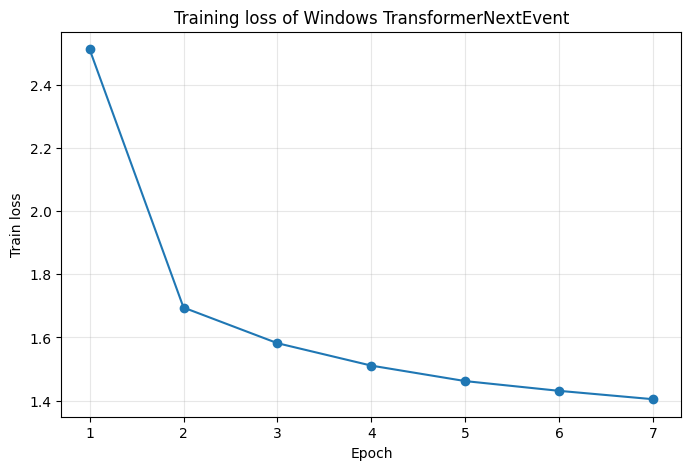

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_history_df["epoch"],
    train_history_df["train_loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Training loss of Windows TransformerNextEvent")
plt.grid(True, alpha=0.3)

plt.savefig(
    f"{PLOTS_DIR}/01_train_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
test_predictions_df = test_seq.copy()

test_predictions_df["model_score"] = test_scores
test_predictions_df["y_true"] = test_predictions_df["final_label"].astype(int)
test_predictions_df["y_pred"] = test_pred
test_predictions_df["is_correct"] = (
    test_predictions_df["y_true"] == test_predictions_df["y_pred"]
)

test_predictions_df["error_type"] = "TN"

test_predictions_df.loc[
    (test_predictions_df["y_true"] == 1) & (test_predictions_df["y_pred"] == 1),
    "error_type"
] = "TP"

test_predictions_df.loc[
    (test_predictions_df["y_true"] == 0) & (test_predictions_df["y_pred"] == 1),
    "error_type"
] = "FP"

test_predictions_df.loc[
    (test_predictions_df["y_true"] == 1) & (test_predictions_df["y_pred"] == 0),
    "error_type"
] = "FN"

NameError: name 'PLOTS_DIR' is not defined

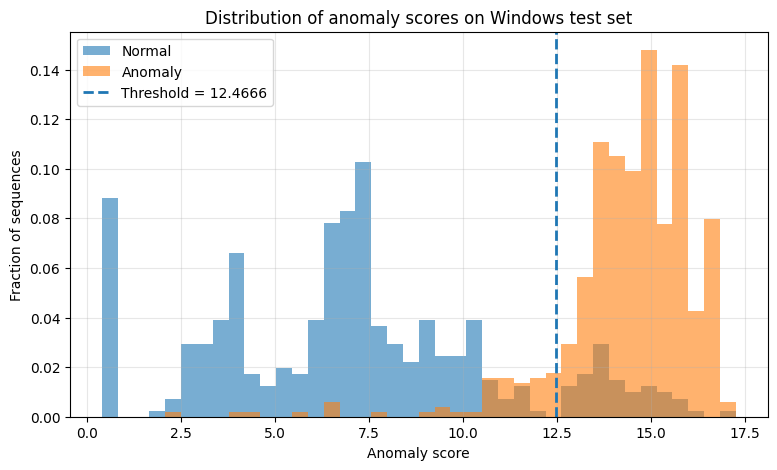

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

test_analysis = test_predictions_df.copy()

normal_scores = test_analysis.loc[
    test_analysis["y_true"] == 0,
    "model_score"
].values

anomaly_scores = test_analysis.loc[
    test_analysis["y_true"] == 1,
    "model_score"
].values

all_scores = np.concatenate([normal_scores, anomaly_scores])
bins = np.linspace(all_scores.min(), all_scores.max(), 41)

plt.figure(figsize=(9, 5))

plt.hist(
    normal_scores,
    bins=bins,
    alpha=0.6,
    label="Normal",
    weights=np.ones_like(normal_scores) / len(normal_scores)
)

plt.hist(
    anomaly_scores,
    bins=bins,
    alpha=0.6,
    label="Anomaly",
    weights=np.ones_like(anomaly_scores) / len(anomaly_scores)
)

plt.axvline(
    best_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {best_threshold:.4f}"
)

plt.xlabel("Anomaly score")
plt.ylabel("Fraction of sequences")
plt.title("Distribution of anomaly scores on Windows test set")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(
    f"{PLOTS_DIR}/03_test_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

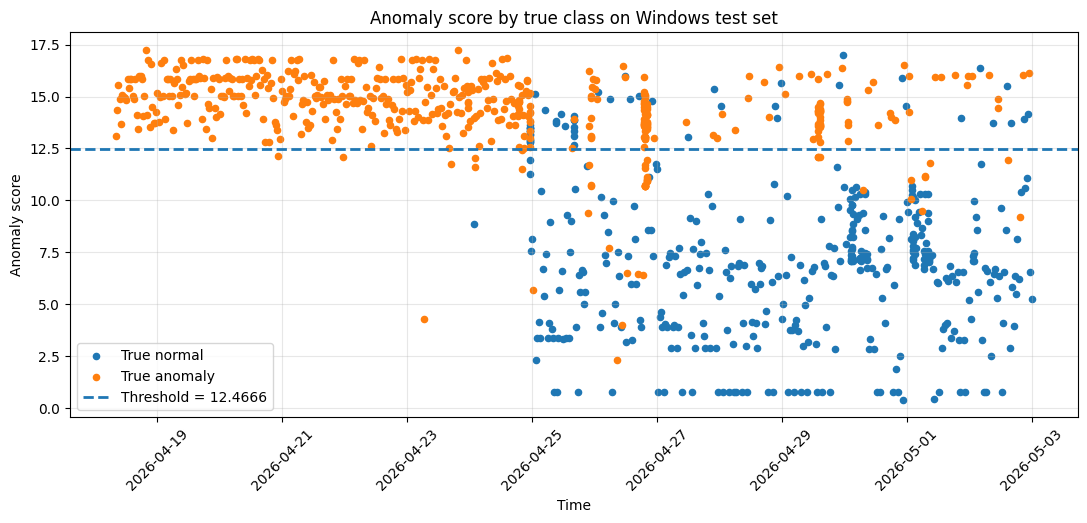

In [ ]:
normal_points = test_time_plot[test_time_plot["true_label"] == 0]
anomaly_points = test_time_plot[test_time_plot["true_label"] == 1]

plt.figure(figsize=(13, 5))

plt.scatter(
    normal_points["WindowStart"],
    normal_points["model_score"],
    s=20,
    label="True normal"
)

plt.scatter(
    anomaly_points["WindowStart"],
    anomaly_points["model_score"],
    s=20,
    label="True anomaly"
)

plt.axhline(
    best_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {best_threshold:.4f}"
)

plt.xlabel("Time")
plt.ylabel("Anomaly score")
plt.title("Anomaly score by true class on Windows test set")
plt.legend()
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.savefig(
    f"{PLOTS_DIR}/10_anomaly_score_by_class_over_time_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

test_analysis = test_predictions_df.copy()

test_analysis["WindowStart"] = pd.to_datetime(test_analysis["WindowStart"])
test_analysis["is_error"] = ~test_analysis["is_correct"]

test_time_plot = test_analysis.sort_values("WindowStart").copy()
errors = test_time_plot[test_time_plot["is_error"]].copy()

NameError: name 'PLOTS_DIR' is not defined

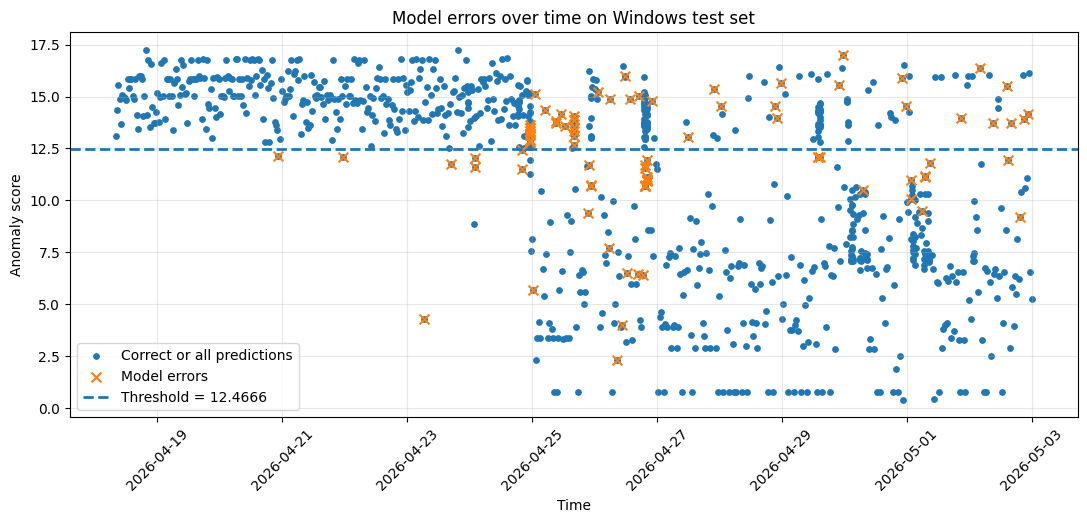

In [ ]:
errors = test_analysis[test_analysis["is_error"]].copy()
errors["WindowStart"] = pd.to_datetime(errors["WindowStart"])

plt.figure(figsize=(13, 5))

plt.scatter(
    test_time_plot["WindowStart"],
    test_time_plot["model_score"],
    s=15,
    label="Correct or all predictions"
)

plt.scatter(
    errors["WindowStart"],
    errors["model_score"],
    s=50,
    marker="x",
    label="Model errors"
)

plt.axhline(
    best_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {best_threshold:.4f}"
)

plt.xlabel("Time")
plt.ylabel("Anomaly score")
plt.title("Model errors over time on Windows test set")
plt.legend()
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.savefig(
    f"{PLOTS_DIR}/11_model_errors_over_time_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

NameError: name 'PLOTS_DIR' is not defined

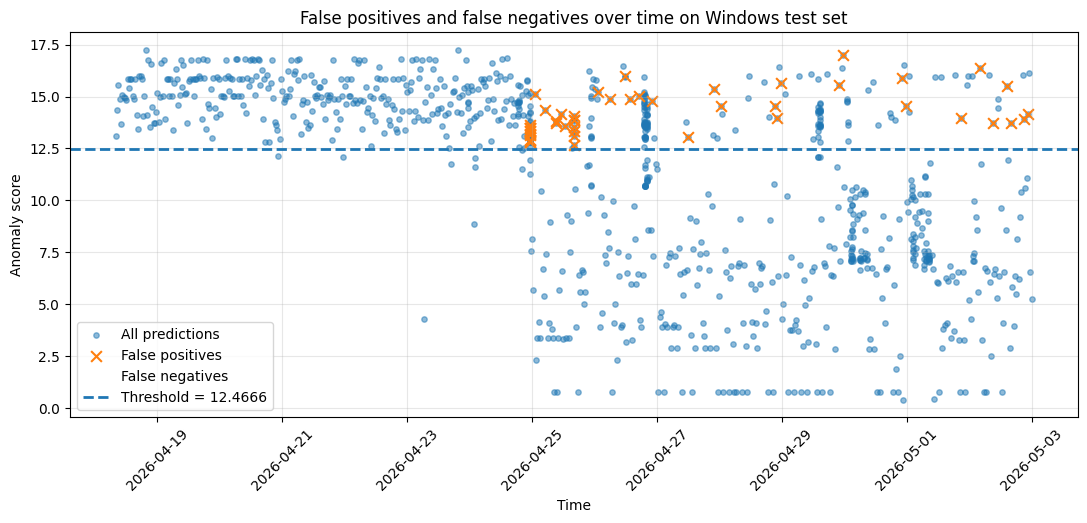

In [ ]:
test_analysis = test_predictions_df.copy()
test_analysis["WindowStart"] = pd.to_datetime(test_analysis["WindowStart"])
test_analysis["is_error"] = ~test_analysis["is_correct"]

test_time_plot = test_analysis.sort_values("WindowStart").copy()

fp = test_time_plot[test_time_plot["error_type"] == "FP"].copy()
fn = test_time_plot[test_time_plot["error_type"] == "FN"].copy()

plt.figure(figsize=(13, 5))

plt.scatter(
    test_time_plot["WindowStart"],
    test_time_plot["model_score"],
    s=15,
    alpha=0.5,
    label="All predictions"
)

plt.scatter(
    fp["WindowStart"],
    fp["model_score"],
    s=60,
    marker="x",
    label="False positives"
)

plt.scatter(
    fn["WindowStart"],
    fn["model_score"],
    s=70,
    marker="o",
    facecolors="none",
    label="False negatives"
)

plt.axhline(
    best_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {best_threshold:.4f}"
)

plt.xlabel("Time")
plt.ylabel("Anomaly score")
plt.title("False positives and false negatives over time on Windows test set")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.savefig(
    f"{PLOTS_DIR}/11_fp_fn_over_time_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
error_by_day = (
    test_analysis
    .assign(day=test_analysis["WindowStart"].dt.date)
    .groupby(["day", "error_type"])
    .size()
    .unstack(fill_value=0)
)

display(error_by_day)

error_type,FN,FP,TN,TP
day,,,,
2026-04-18,0,0,0,32
2026-04-19,0,0,0,48
2026-04-20,1,0,0,47
2026-04-21,1,0,0,47
2026-04-22,0,0,0,48
2026-04-23,2,0,0,50
2026-04-24,4,12,4,65
2026-04-25,5,13,35,12
2026-04-26,20,6,28,54


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

daily_metrics = []

for day, g in test_analysis.assign(day=test_analysis["WindowStart"].dt.date).groupby("day"):
    y_true_day = g["y_true"].astype(int).values
    y_pred_day = g["y_pred"].astype(int).values

    daily_metrics.append({
        "day": day,
        "n": len(g),
        "normal": int((y_true_day == 0).sum()),
        "anomaly": int((y_true_day == 1).sum()),
        "accuracy": accuracy_score(y_true_day, y_pred_day),
        "precision": precision_score(y_true_day, y_pred_day, zero_division=0),
        "recall": recall_score(y_true_day, y_pred_day, zero_division=0),
        "f1": f1_score(y_true_day, y_pred_day, zero_division=0),
        "mean_score": g["model_score"].mean(),
        "median_score": g["model_score"].median(),
        "mean_unk_ratio": g["unk_ratio"].mean() if "unk_ratio" in g.columns else np.nan,
    })

daily_metrics_df = pd.DataFrame(daily_metrics)

display(daily_metrics_df)

,day,n,normal,anomaly,accuracy,precision,recall,f1,mean_score,median_score,mean_unk_ratio
0,2026-04-18,32,0,32,1.000000,1.000000,1.000000,1.000000,14.968264,14.933869,0.104526
1,2026-04-19,48,0,48,1.000000,1.000000,1.000000,1.000000,15.362840,15.706946,0.114828
2,2026-04-20,48,0,48,0.979167,1.000000,0.979167,0.989474,15.331408,15.613087,0.115850
3,2026-04-21,48,0,48,0.979167,1.000000,0.979167,0.989474,14.972914,15.000610,0.097513
4,2026-04-22,48,0,48,1.000000,1.000000,1.000000,1.000000,14.951832,14.887853,0.104203
5,2026-04-23,52,0,52,0.961538,1.000000,0.961538,0.980392,14.729176,14.862040,0.181365
6,2026-04-24,85,16,69,0.811765,0.844156,0.942029,0.890411,14.102224,14.186763,0.468959
7,2026-04-25,65,48,17,0.723077,0.480000,0.705882,0.571429,9.058160,9.277884,0.312284
8,2026-04-26,108,34,74,0.759259,0.900000,0.729730,0.805970,11.354319,13.059489,0.587528
9,2026-04-27,48,45,3,0.958333,0.600000,1.000000,0.750000,6.130793,6.187927,0.013462


In [ ]:
fn_cases = test_analysis[test_analysis["error_type"] == "FN"].copy()

display_cols = [
    "AnnotationID",
    "StableID",
    "WindowStart",
    "WindowEnd",
    "SeqLen",
    "model_score",
    "unk_ratio",
    "num_unk",
    "final_score",
    "final_confidence",
    "llm1_key_events",
    "llm1_reason",
]

display_cols = [c for c in display_cols if c in fn_cases.columns]

display(
    fn_cases
    .sort_values(["WindowStart", "model_score"])
    [display_cols]
    .head(30)
)

,AnnotationID,StableID,WindowStart,WindowEnd,SeqLen,model_score,unk_ratio,num_unk,final_score,final_confidence,llm1_key_events,llm1_reason
900,900,test_2026-04-20 22:30:00_2026-04-20 23:00:00_0...,2026-04-20 22:30:00,2026-04-20 23:00:00,32,12.111812,0.093750,3,0.84,0.91,"WER 1001, SQLException64, sqlservr.exe, SceCli...","Обычные backup/update/GPO события, но WER 1001..."
950,950,test_2026-04-21 23:30:00_2026-04-22 00:00:00_0...,2026-04-21 23:30:00,2026-04-22 00:00:00,31,12.108974,0.290323,9,0.89,0.92,"WER 1001, SQLException64, sqlservr.exe, MSSQLS...","SQL backups нормальны, но повторные WER 1001 п..."
1012,1012,test_2026-04-23 06:30:00_2026-04-23 07:00:00_0...,2026-04-23 06:30:00,2026-04-23 07:00:00,15,4.282271,0.066667,1,0.84,0.93,WER 1001 SQLException64 sqlservr.exe,Два последовательных WER 1001 по sqlservr.exe;...
1033,1033,test_2026-04-23 17:00:00_2026-04-23 17:30:00_0...,2026-04-23 17:00:00,2026-04-23 17:30:00,36,11.740856,0.472222,17,0.98,0.99,MSSQLSERVER 17832 Error массово; WER 1001 SQLE...,Массовые MSSQLSERVER Error 17832 с разных клие...
1057,1057,test_2026-04-24 02:00:00_2026-04-24 02:30:00_1...,2026-04-24 02:00:00,2026-04-24 02:30:00,64,11.599500,0.015625,1,0.86,0.92,WER 1001 SQLException64 sqlservr.exe; MSSQLSER...,Повторяющиеся Windows Error Reporting 1001 по ...
1056,1056,test_2026-04-24 02:00:00_2026-04-24 02:30:00_0...,2026-04-24 02:00:00,2026-04-24 02:30:00,64,12.041607,0.015625,1,0.78,0.86,WER 1001 SQLException64 sqlservr.exe; MSSQLSER...,Есть WER 1001 по sqlservr.exe на фоне большого...
1103,1103,test_2026-04-24 20:00:00_2026-04-24 20:30:00_2...,2026-04-24 20:00:00,2026-04-24 20:30:00,64,11.529051,0.828125,53,0.98,0.99,"MSSQLSERVER 17832 Error, SQLSERVERAGENT 208, M...",Массовые ошибки MSSQLSERVER 17832 с разных кли...
1102,1102,test_2026-04-24 20:00:00_2026-04-24 20:30:00_1...,2026-04-24 20:00:00,2026-04-24 20:30:00,64,12.431419,0.796875,51,0.99,0.99,"MSSQLSERVER 17832 Error, SQLSERVERAGENT 208, M...",Очень высокая плотность MSSQLSERVER 17832 Erro...
1137,1137,test_2026-04-25 00:30:00_2026-04-25 01:00:00_0...,2026-04-25 00:30:00,2026-04-25 01:00:00,31,5.692328,0.000000,0,0.94,0.97,MSSQLSERVER 4014 Error; Token W1671; repeated ...,Повторяющиеся MSSQLSERVER 4014 Error: fatal er...
1187,1187,test_2026-04-25 21:30:00_2026-04-25 22:00:00_0...,2026-04-25 21:30:00,2026-04-25 22:00:00,18,9.406201,0.000000,0,0.99,0.99,MSSQLSERVER 17053 Error; MSSQLSERVER 9002 Erro...,Явная SQL-аномалия: ошибка нехватки места на д...


In [ ]:
display(
    test_analysis
    .groupby("error_type")[["model_score", "num_unk", "unk_ratio"]]
    .agg(["count", "mean", "median", "min", "max"])
)

model_score                                             num_unk  \
                 count       mean     median        min        max   count   
error_type                                                                   
FN                  45  10.141538  10.954016   2.293527  12.431419      45   
FP                  48  14.165849  13.883580  12.645302  16.987167      48   
TN                 361   6.152874   6.714649   0.398798  11.965529     361   
TP                 469  14.846509  14.871570  12.507346  17.257750     469   

                                     unk_ratio                                \
                 mean median min max     count      mean    median       min   
error_type                                                                     
FN          30.888889   17.0   0  64        45  0.493211  0.472222  0.000000   
FP          27.375000    7.0   1  64        48  0.459866  0.200403  0.029412   
TN           0.462604    0.0   0  64       361  0.009702  0.000000  0.000000   
TP          16.494670    3.0   1  63       469  0.304589  0.117647  0.020833   

                      
                 max  
error_type            
FN          1.000000  
FP          1.000000  
TN          1.000000  
TP          0.984375

In [ ]:
def stable_hash_bucket(token, num_buckets=NUM_UNK_BUCKETS):
    h = hashlib.md5(str(token).encode("utf-8")).hexdigest()
    return int(h, 16) % num_buckets


def encode_token_existing_vocab(token):
    if token in token_to_idx:
        return token_to_idx[token]

    bucket = stable_hash_bucket(token, NUM_UNK_BUCKETS)
    return UNK_OFFSET + bucket


def encode_sequence_existing_vocab(seq):
    """
    Кодирует sequence через словарь Server A.
    Если Features случайно загружены как строка из CSV, пытаемся преобразовать их обратно в list.
    """
    if isinstance(seq, str):
        try:
            seq = ast.literal_eval(seq)
        except Exception:
            seq = [seq]

    return [encode_token_existing_vocab(token) for token in seq]


def is_unk_id(x):
    return UNK_OFFSET <= x < UNK_OFFSET + NUM_UNK_BUCKETS


def unk_ratio(encoded_seq):
    if len(encoded_seq) == 0:
        return 0.0

    return sum(is_unk_id(x) for x in encoded_seq) / len(encoded_seq)


def add_encoding_with_server_a_vocab(df, name="df"):
    df = df.copy()

    df["EncodedFeatures"] = df["Features"].apply(encode_sequence_existing_vocab)
    df["unk_ratio"] = df["EncodedFeatures"].apply(unk_ratio)

    print(f"{name}: encoded")
    print(f"{name} UNK ratio:")
    print(df["unk_ratio"].describe())

    return df

In [ ]:
def evaluate_with_threshold(y_true, scores, threshold):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores)
    y_pred = (scores >= threshold).astype(int)

    result = {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "classification_report": classification_report(
            y_true,
            y_pred,
            digits=4,
            zero_division=0
        )
    }

    if len(np.unique(y_true)) > 1:
        result["roc_auc"] = roc_auc_score(y_true, scores)
        result["pr_auc"] = average_precision_score(y_true, scores)
    else:
        result["roc_auc"] = np.nan
        result["pr_auc"] = np.nan

    return result, y_pred


def print_eval_result(title, result):
    print("=" * 80)
    print(title)
    print("=" * 80)

    print("threshold:", result["threshold"])
    print("accuracy:", result["accuracy"])
    print("precision:", result["precision"])
    print("recall:", result["recall"])
    print("f1:", result["f1"])
    print("roc_auc:", result["roc_auc"])
    print("pr_auc:", result["pr_auc"])

    print("\nConfusion matrix:")
    print(result["confusion_matrix"])

    print("\nClassification report:")
    print(result["classification_report"])

In [ ]:
from google.colab import drive
import os

mount_point = "/content/gdrive"
os.makedirs(mount_point, exist_ok=True)

drive.mount(mount_point)

Mounted at /content/gdrive


Server B

In [ ]:
SERVER_B_EXPORT_DIR = "/content/gdrive/MyDrive/windows_logs_project/payment_serverB_export_30min"

SERVER_B_LABELS_PATH = "/content/ServerB.xlsx"

print("SERVER_B_EXPORT_DIR exists:", os.path.exists(SERVER_B_EXPORT_DIR))
print("SERVER_B_LABELS_PATH exists:", os.path.exists(SERVER_B_LABELS_PATH))

print("\nFiles in SERVER_B_EXPORT_DIR:")
print(os.listdir(SERVER_B_EXPORT_DIR))

SERVER_B_EXPORT_DIR exists: True
SERVER_B_LABELS_PATH exists: True

Files in SERVER_B_EXPORT_DIR:
['val_seq.pkl', 'test_seq.pkl', 'val_seq_raw.pkl', 'test_seq_raw.pkl', 'annotation_df.pkl', 'template_to_id.pkl', 'id_to_template.pkl', 'template_to_id.json', 'id_to_template.json', 'val_seq_B.csv', 'test_seqB.csv', 'annotation_dfB.csv']


In [ ]:
possible_val_names = [
    "val_seq.pkl",
    "val_B.pkl",
    "validation_B.pkl"
]

possible_test_names = [
    "test_seq.pkl",
    "test_B.pkl"
]

def load_first_existing_pickle(folder, possible_names):
    for name in possible_names:
        path = os.path.join(folder, name)
        if os.path.exists(path):
            print("Loaded:", path)
            return pd.read_pickle(path)

    raise FileNotFoundError(
        f"Не найден ни один файл из {possible_names} в {folder}"
    )

val_B = load_first_existing_pickle(SERVER_B_EXPORT_DIR, possible_val_names)
test_B = load_first_existing_pickle(SERVER_B_EXPORT_DIR, possible_test_names)

print("val_B:", val_B.shape)
print("test_B:", test_B.shape)

print("\nval_B columns:")
print(val_B.columns.tolist())

Loaded: /content/gdrive/MyDrive/windows_logs_project/payment_serverB_export_30min/val_seq.pkl
Loaded: /content/gdrive/MyDrive/windows_logs_project/payment_serverB_export_30min/test_seq.pkl
val_B: (731, 31)
test_B: (731, 31)

val_B columns:
['WindowSize', 'WindowStart', 'WindowEnd', 'Features', 'TimeInterval', 'Latency', 'SeqLen', 'LogNames', 'Sources', 'Levels', 'EventIDs', 'EventLogNames', 'EventSources', 'EventLevels', 'EventIDsPerEvent', 'EventTokens', 'RawMessages', 'ReviewTemplates', 'Label', 'WeakLabel', 'HardWeakLabel', 'HardSuspiciousReason', 'SoftSuspiciousReason', 'SuspiciousReason', 'NeedsReview', 'Split', 'ChunkID', 'OriginalSeqLen', 'ChunkStartPos', 'ChunkEndPos', 'WasChunked']


In [ ]:
ann_B = pd.read_excel(SERVER_B_LABELS_PATH)
ann_B.columns = ann_B.columns.str.strip()

print("ann_B:", ann_B.shape)
print("ann_B columns:")
print(ann_B.columns.tolist())

required_ann_cols_B = ["AnnotationID", "StableID", "Split", "label"]

missing_cols = [c for c in required_ann_cols_B if c not in ann_B.columns]
if missing_cols:
    raise ValueError(f"В ServerB.xlsx нет колонок: {missing_cols}")

ann_B["AnnotationID"] = ann_B["AnnotationID"].astype(int)
ann_B["label"] = pd.to_numeric(ann_B["label"], errors="coerce")

if ann_B["label"].isna().any():
    display(ann_B[ann_B["label"].isna()].head(20))
    raise ValueError("В ServerB.xlsx есть пустые label.")

ann_B["label"] = ann_B["label"].astype(int)

invalid_labels = ~ann_B["label"].isin([0, 1])
if invalid_labels.any():
    display(ann_B[invalid_labels])
    raise ValueError("label должен быть только 0 или 1.")

print("\nSplit distribution:")
print(ann_B["Split"].value_counts(dropna=False))

print("\nLabel distribution:")
print(ann_B["label"].value_counts(dropna=False))

print("\nLabel distribution by split:")
print(ann_B.groupby("Split")["label"].value_counts(dropna=False))

ann_B: (1462, 12)
ann_B columns:
['AnnotationID', 'StableID', 'Split', 'WindowStart', 'WindowEnd', 'SeqLen', 'label', 'anomaly_score', 'confidence', 'key_events', 'reason', 'annotator']

Split distribution:
Split
validation_B    731
test_B          731
Name: count, dtype: int64

Label distribution:
label
0    1458
1       4
Name: count, dtype: int64

Label distribution by split:
Split         label
test_B        0        729
              1          2
validation_B  0        729
              1          2
Name: count, dtype: int64


In [ ]:
annotation_B = pd.concat([val_B, test_B], axis=0).reset_index(drop=True)

if "AnnotationID" not in annotation_B.columns:
    annotation_B["AnnotationID"] = range(len(annotation_B))
if "StableID" not in annotation_B.columns:
    annotation_B["StableID"] = (
        annotation_B["Split"].astype(str) + "_" +
        annotation_B["WindowStart"].astype(str) + "_" +
        annotation_B["WindowEnd"].astype(str) + "_" +
        annotation_B["ChunkID"].astype(str) + "_" +
        annotation_B["ChunkStartPos"].astype(str) + "_" +
        annotation_B["ChunkEndPos"].astype(str)
    )

annotation_B["AnnotationID"] = annotation_B["AnnotationID"].astype(int)

print("annotation_B:", annotation_B.shape)
print("ann_B:", ann_B.shape)

display(annotation_B[["AnnotationID", "StableID", "Split"]].head())
display(ann_B[["AnnotationID", "StableID", "Split", "label"]].head())

annotation_B: (1462, 33)
ann_B: (1462, 12)


,AnnotationID,StableID,Split
0,0,validation_B_2026-04-04 21:00:00_2026-04-04 21...,validation_B
1,1,validation_B_2026-04-04 21:30:00_2026-04-04 22...,validation_B
2,2,validation_B_2026-04-04 22:00:00_2026-04-04 22...,validation_B
3,3,validation_B_2026-04-04 22:30:00_2026-04-04 23...,validation_B
4,4,validation_B_2026-04-04 23:00:00_2026-04-04 23...,validation_B


,AnnotationID,StableID,Split,label
0,0,validation_B_2026-04-04 21:00:00_2026-04-04 21...,validation_B,0
1,1,validation_B_2026-04-04 21:30:00_2026-04-04 22...,validation_B,0
2,2,validation_B_2026-04-04 22:00:00_2026-04-04 22...,validation_B,0
3,3,validation_B_2026-04-04 22:30:00_2026-04-04 23...,validation_B,0
4,4,validation_B_2026-04-04 23:00:00_2026-04-04 23...,validation_B,0


In [ ]:

server_B_labeled = annotation_B.merge(
    ann_B[["AnnotationID", "StableID", "label"]],
    on=["AnnotationID", "StableID"],
    how="inner"
)

print("annotation_B rows:", len(annotation_B))
print("server_B_labeled rows:", len(server_B_labeled))

if len(server_B_labeled) != len(annotation_B):
    print("WARNING: merge по AnnotationID + StableID потерял строки.")
    print("Пробую fallback merge только по AnnotationID...")

    server_B_labeled = annotation_B.merge(
        ann_B[["AnnotationID", "label"]],
        on="AnnotationID",
        how="inner"
    )

    print("server_B_labeled rows after fallback:", len(server_B_labeled))

if len(server_B_labeled) != len(annotation_B):
    raise ValueError("Merge Server B всё ещё потерял строки. Нужно проверить AnnotationID/StableID.")

print("\nLabel distribution by split:")
print(server_B_labeled.groupby("Split")["label"].value_counts())

annotation_B rows: 1462
server_B_labeled rows: 1462

Label distribution by split:
Split         label
test_B        0        729
              1          2
validation_B  0        729
              1          2
Name: count, dtype: int64


In [ ]:
val_B_labeled = server_B_labeled[
    server_B_labeled["Split"] == "validation_B"
].copy()

test_B_labeled = server_B_labeled[
    server_B_labeled["Split"] == "test_B"
].copy()

print("val_B_labeled:", val_B_labeled.shape)
print("test_B_labeled:", test_B_labeled.shape)

print("\nvalidation_B labels:")
print(val_B_labeled["label"].value_counts())

print("\ntest_B labels:")
print(test_B_labeled["label"].value_counts())

if len(val_B_labeled) == 0 or len(test_B_labeled) == 0:
    raise ValueError("validation_B или test_B пустой. Проверь значения Split.")

val_B_labeled: (731, 34)
test_B_labeled: (731, 34)

validation_B labels:
label
0    729
1      2
Name: count, dtype: int64

test_B labels:
label
0    729
1      2
Name: count, dtype: int64


In [ ]:
val_B_labeled = add_encoding_with_server_a_vocab(
    val_B_labeled,
    name="validation_B"
)

test_B_labeled = add_encoding_with_server_a_vocab(
    test_B_labeled,
    name="test_B"
)

validation_B: encoded
validation_B UNK ratio:
count    731.000000
mean       0.997974
std        0.009653
min        0.911765
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: unk_ratio, dtype: float64
test_B: encoded
test_B UNK ratio:
count    731.000000
mean       0.997454
std        0.010524
min        0.921053
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: unk_ratio, dtype: float64


In [ ]:
y_val_B = val_B_labeled["label"].astype(int).values
y_test_B = test_B_labeled["label"].astype(int).values

print("Scoring validation_B...")
scores_val_B_result = compute_scores_for_df(
    val_B_labeled,
    model,
    method=best_method
)

print("Scoring test_B...")
scores_test_B_result = compute_scores_for_df(
    test_B_labeled,
    model,
    method=best_method
)

def extract_scores(result):
    if isinstance(result, tuple) or isinstance(result, list):
        return np.asarray(result[0])
    return np.asarray(result)

scores_val_B = extract_scores(scores_val_B_result)
scores_test_B = extract_scores(scores_test_B_result)

print("len(scores_val_B):", len(scores_val_B))
print("len(val_B_labeled):", len(val_B_labeled))

print("len(scores_test_B):", len(scores_test_B))
print("len(test_B_labeled):", len(test_B_labeled))

assert len(scores_val_B) == len(val_B_labeled), "scores_val_B length mismatch"
assert len(scores_test_B) == len(test_B_labeled), "scores_test_B length mismatch"

val_B_labeled["anomaly_score"] = scores_val_B
test_B_labeled["anomaly_score"] = scores_test_B

print("validation_B score stats:")
print(val_B_labeled["anomaly_score"].describe())

print("\ntest_B score stats:")
print(test_B_labeled["anomaly_score"].describe())

Scoring validation_B...


Scoring (max, known targets only):   0%|          | 0/731 [00:00<?, ?it/s]

Scoring test_B...


Scoring (max, known targets only):   0%|          | 0/731 [00:00<?, ?it/s]

len(scores_val_B): 731
len(val_B_labeled): 731
len(scores_test_B): 731
len(test_B_labeled): 731
validation_B score stats:
count    731.000000
mean      14.248806
std        0.244693
min       13.131681
25%       14.185243
50%       14.317001
75%       14.350235
max       15.186545
Name: anomaly_score, dtype: float64

test_B score stats:
count    731.000000
mean      14.234304
std        0.256216
min       13.005895
25%       14.185243
50%       14.310556
75%       14.349943
max       14.849665
Name: anomaly_score, dtype: float64


In [ ]:
threshold_A = best_threshold

print("threshold_A:", threshold_A)
print("best_method:", best_method)

threshold_A: 12.466619491577148
best_method: max


In [ ]:
zero_val_B_eval, zero_val_B_pred = evaluate_with_threshold(
    y_val_B,
    scores_val_B,
    threshold_A
)

zero_test_B_eval, zero_test_B_pred = evaluate_with_threshold(
    y_test_B,
    scores_test_B,
    threshold_A
)

val_B_labeled["pred_zero_shot_threshold_A"] = zero_val_B_pred
test_B_labeled["pred_zero_shot_threshold_A"] = zero_test_B_pred

print_eval_result(
    "ZERO-SHOT Server B validation with threshold_A",
    zero_val_B_eval
)

print_eval_result(
    "ZERO-SHOT Server B test with threshold_A",
    zero_test_B_eval
)

ZERO-SHOT Server B validation with threshold_A
threshold: 12.466619491577148
accuracy: 0.0027359781121751026
precision: 0.0027359781121751026
recall: 1.0
f1: 0.005457025920873124
roc_auc: 0.0048010973936900014
pr_auc: 0.0020623316077861536

Confusion matrix:
[[  0 729]
 [  0   2]]

Classification report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       729
           1     0.0027    1.0000    0.0055         2

    accuracy                         0.0027       731
   macro avg     0.0014    0.5000    0.0027       731
weighted avg     0.0000    0.0027    0.0000       731

ZERO-SHOT Server B test with threshold_A
threshold: 12.466619491577148
accuracy: 0.0027359781121751026
precision: 0.0027359781121751026
recall: 1.0
f1: 0.005457025920873124
roc_auc: 0.144718792866941
pr_auc: 0.002305236270753512

Confusion matrix:
[[  0 729]
 [  0   2]]

Classification report:
              precision    recall  f1-score   support

           0     

In [ ]:
print("Score stats Server B validation:")
print(pd.Series(scores_val_B).describe())

print("\nScore stats by label on validation_B:")
display(
    pd.DataFrame({
        "score": scores_val_B,
        "label": y_val_B
    }).groupby("label")["score"].describe()
)

print("\nUNK ratio by label on validation_B:")
display(
    val_B_labeled.groupby("label")["unk_ratio"].describe()
)

Score stats Server B validation:
count    731.000000
mean      14.248806
std        0.244693
min       13.131681
25%       14.185243
50%       14.317001
75%       14.350235
max       15.186545
dtype: float64

Score stats by label on validation_B:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,729.0,14.251424,0.239836,13.131681,14.185243,14.317060,14.350236,15.186545
1,2.0,13.294422,0.080023,13.237837,13.266129,13.294422,13.322714,13.351007



UNK ratio by label on validation_B:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,729.0,0.998183,0.008784,0.933333,1.000000,1.000000,1.000000,1.000000
1,2.0,0.921791,0.014180,0.911765,0.916778,0.921791,0.926805,0.931818


In [ ]:
normal_scores_val_B = scores_val_B[y_val_B == 0]

threshold_candidates_B = {}

for p in [90, 95, 97, 99, 99.5, 99.9]:
    threshold_candidates_B[f"p{p}"] = np.percentile(normal_scores_val_B, p)

threshold_candidates_B["max_normal_val_B"] = np.max(normal_scores_val_B)
threshold_candidates_B["threshold_A"] = threshold_A

for name, thr in threshold_candidates_B.items():
    eval_val_B, pred_val_B = evaluate_with_threshold(
        y_val_B,
        scores_val_B,
        thr
    )

    print_eval_result(
        f"validation_B threshold candidate: {name}",
        eval_val_B
    )

validation_B threshold candidate: p90
threshold: 14.44424648284912
accuracy: 0.8974008207934336
precision: 0.0
recall: 0.0
f1: 0.0
roc_auc: 0.0048010973936900014
pr_auc: 0.0020623316077861536

Confusion matrix:
[[656  73]
 [  2   0]]

Classification report:
              precision    recall  f1-score   support

           0     0.9970    0.8999    0.9459       729
           1     0.0000    0.0000    0.0000         2

    accuracy                         0.8974       731
   macro avg     0.4985    0.4499    0.4730       731
weighted avg     0.9942    0.8974    0.9433       731

validation_B threshold candidate: p95
threshold: 14.544468307495118
accuracy: 0.9466484268125855
precision: 0.0
recall: 0.0
f1: 0.0
roc_auc: 0.0048010973936900014
pr_auc: 0.0020623316077861536

Confusion matrix:
[[692  37]
 [  2   0]]

Classification report:
              precision    recall  f1-score   support

           0     0.9971    0.9492    0.9726       729
           1     0.0000    0.0000    0.0000    

In [ ]:
threshold_B = np.percentile(normal_scores_val_B, 99.5)

print("threshold_A:", threshold_A)
print("threshold_B:", threshold_B)

threshold_A: 12.466619491577148
threshold_B: 14.80560848236084


In [ ]:
test_B_eval_calibrated, test_B_pred_calibrated = evaluate_with_threshold(
    y_test_B,
    scores_test_B,
    threshold_B
)

test_B_labeled["pred_threshold_B"] = test_B_pred_calibrated

print_eval_result(
    "SERVER B TEST after threshold_B calibration",
    test_B_eval_calibrated
)

SERVER B TEST after threshold_B calibration
threshold: 14.80560848236084
accuracy: 0.9945280437756497
precision: 0.0
recall: 0.0
f1: 0.0
roc_auc: 0.144718792866941
pr_auc: 0.002305236270753512

Confusion matrix:
[[727   2]
 [  2   0]]

Classification report:
              precision    recall  f1-score   support

           0     0.9973    0.9973    0.9973       729
           1     0.0000    0.0000    0.0000         2

    accuracy                         0.9945       731
   macro avg     0.4986    0.4986    0.4986       731
weighted avg     0.9945    0.9945    0.9945       731



Server C

In [ ]:
SERVER_C_EXPORT_DIR = "/content/gdrive/MyDrive/windows_logs_project/serverC_22_export_30min"
SERVER_C_LABELS_PATH = "/content/разметка сервера C_annotated (1).xlsx"

print("SERVER_C_EXPORT_DIR exists:", os.path.exists(SERVER_C_EXPORT_DIR))
print("SERVER_C_LABELS_PATH exists:", os.path.exists(SERVER_C_LABELS_PATH))

print("\nFiles in SERVER_C_EXPORT_DIR:")
print(os.listdir(SERVER_C_EXPORT_DIR))

SERVER_C_EXPORT_DIR exists: True
SERVER_C_LABELS_PATH exists: True

Files in SERVER_C_EXPORT_DIR:
['val_C.pkl', 'test_C.pkl', 'val_C_raw.pkl', 'test_C_raw.pkl', 'annotation_df_C.pkl', 'template_to_id.pkl', 'id_to_template.pkl', 'template_to_id.json', 'id_to_template.json', 'val_C.csv', 'test_C.csv', 'annotation_df_C.csv', 'serverC_22_data_30min.pkl']


In [ ]:
possible_val_C_names = [
    "val_C.pkl",
    "val_seq.pkl",
    "validation_C.pkl"
]

possible_test_C_names = [
    "test_C.pkl",
    "test_seq.pkl"
]

val_C = load_first_existing_pickle(SERVER_C_EXPORT_DIR, possible_val_C_names)
test_C = load_first_existing_pickle(SERVER_C_EXPORT_DIR, possible_test_C_names)

print("val_C:", val_C.shape)
print("test_C:", test_C.shape)

print("\nval_C columns:")
print(val_C.columns.tolist())

Loaded: /content/gdrive/MyDrive/windows_logs_project/serverC_22_export_30min/val_C.pkl
Loaded: /content/gdrive/MyDrive/windows_logs_project/serverC_22_export_30min/test_C.pkl
val_C: (300, 31)
test_C: (1473, 31)

val_C columns:
['WindowSize', 'WindowStart', 'WindowEnd', 'Features', 'TimeInterval', 'Latency', 'SeqLen', 'LogNames', 'Sources', 'Levels', 'EventIDs', 'EventLogNames', 'EventSources', 'EventLevels', 'EventIDsPerEvent', 'EventTokens', 'RawMessages', 'ReviewTemplates', 'Label', 'WeakLabel', 'HardWeakLabel', 'HardSuspiciousReason', 'SoftSuspiciousReason', 'SuspiciousReason', 'NeedsReview', 'Split', 'ChunkID', 'OriginalSeqLen', 'ChunkStartPos', 'ChunkEndPos', 'WasChunked']


In [ ]:
ann_C_raw = pd.read_excel(SERVER_C_LABELS_PATH)
ann_C_raw.columns = ann_C_raw.columns.astype(str).str.strip()

print("ann_C_raw:", ann_C_raw.shape)
print("ann_C_raw columns:")
print(ann_C_raw.columns.tolist())

ann_C_raw: (1773, 23)
ann_C_raw columns:
['AnnotationID', 'StableID', 'Split', 'WindowStart', 'WindowEnd', 'SeqLen', 'Levels', 'Sources', 'EventIDs', 'SuspiciousReason', 'Prompt', 'AnnotationID.1', 'StableID.1', 'Split.1', 'WindowStart.1', 'WindowEnd.1', 'SeqLen.1', 'label', 'anomaly_score', 'confidence', 'key_events', 'reason', 'annotator']


In [ ]:
if all(c in ann_C_raw.columns for c in ["AnnotationID", "StableID", "Split", "label"]):
    ann_C = ann_C_raw.copy()
else:
    cols = ann_C_raw.columns.tolist()
    annotation_id_positions = [i for i, c in enumerate(cols) if c == "AnnotationID"]

    if len(annotation_id_positions) >= 2:
        start = annotation_id_positions[1]
        ann_C = ann_C_raw.iloc[:, start:].copy()
        ann_C.columns = [
            "AnnotationID",
            "StableID",
            "Split",
            "WindowStart",
            "WindowEnd",
            "SeqLen",
            "label",
            "annotation_score",
            "confidence",
            "key_events",
            "reason",
            "annotator"
        ][:ann_C.shape[1]]
    else:
        raise ValueError(
            "Не могу автоматически распознать формат Server C annotation. "
            "Покажи список колонок ann_C_raw."
        )

ann_C.columns = ann_C.columns.astype(str).str.strip()

required_ann_cols_C = ["AnnotationID", "StableID", "Split", "label"]
missing_cols_C = [c for c in required_ann_cols_C if c not in ann_C.columns]

if missing_cols_C:
    raise ValueError(f"В Server C annotation нет колонок: {missing_cols_C}")

ann_C["AnnotationID"] = ann_C["AnnotationID"].astype(int)
ann_C["label"] = pd.to_numeric(ann_C["label"], errors="coerce")

if ann_C["label"].isna().any():
    display(ann_C[ann_C["label"].isna()].head(20))
    raise ValueError("В Server C annotation есть пустые label.")

ann_C["label"] = ann_C["label"].astype(int)

invalid_labels_C = ~ann_C["label"].isin([0, 1])
if invalid_labels_C.any():
    display(ann_C[invalid_labels_C])
    raise ValueError("label должен быть только 0 или 1.")

print("ann_C:", ann_C.shape)

print("\nSplit distribution:")
print(ann_C["Split"].value_counts(dropna=False))

print("\nLabel distribution:")
print(ann_C["label"].value_counts(dropna=False))

print("\nLabel distribution by split:")
print(ann_C.groupby("Split")["label"].value_counts(dropna=False))

ann_C: (1773, 23)

Split distribution:
Split
test_C    1473
val_C      300
Name: count, dtype: int64

Label distribution:
label
0    974
1    799
Name: count, dtype: int64

Label distribution by split:
Split   label
test_C  1        750
        0        723
val_C   0        251
        1         49
Name: count, dtype: int64


In [ ]:
annotation_C = pd.concat([val_C, test_C], axis=0).reset_index(drop=True)

if "AnnotationID" not in annotation_C.columns:
    annotation_C["AnnotationID"] = range(len(annotation_C))

if "StableID" not in annotation_C.columns:
    annotation_C["StableID"] = (
        annotation_C["Split"].astype(str) + "_" +
        annotation_C["WindowStart"].astype(str) + "_" +
        annotation_C["WindowEnd"].astype(str) + "_" +
        annotation_C["ChunkID"].astype(str) + "_" +
        annotation_C["ChunkStartPos"].astype(str) + "_" +
        annotation_C["ChunkEndPos"].astype(str)
    )

annotation_C["AnnotationID"] = annotation_C["AnnotationID"].astype(int)

server_C_labeled = annotation_C.merge(
    ann_C[["AnnotationID", "StableID", "label"]],
    on=["AnnotationID", "StableID"],
    how="inner"
)

print("annotation_C rows:", len(annotation_C))
print("server_C_labeled rows:", len(server_C_labeled))

if len(server_C_labeled) != len(annotation_C):
    print("WARNING: merge по AnnotationID + StableID потерял строки.")
    print("Пробую fallback merge только по AnnotationID...")

    server_C_labeled = annotation_C.merge(
        ann_C[["AnnotationID", "label"]],
        on="AnnotationID",
        how="inner"
    )

    print("server_C_labeled rows after fallback:", len(server_C_labeled))

if len(server_C_labeled) != len(annotation_C):
    raise ValueError("Merge Server C всё ещё потерял строки. Нужно проверить AnnotationID/StableID.")

print("\nLabel distribution by split:")
print(server_C_labeled.groupby("Split")["label"].value_counts())

annotation_C rows: 1773
server_C_labeled rows: 1773

Label distribution by split:
Split   label
test_C  1        750
        0        723
val_C   0        251
        1         49
Name: count, dtype: int64


In [ ]:
val_C_labeled = server_C_labeled[
    server_C_labeled["Split"] == "val_C"
].copy()

test_C_labeled = server_C_labeled[
    server_C_labeled["Split"] == "test_C"
].copy()

print("val_C_labeled:", val_C_labeled.shape)
print("test_C_labeled:", test_C_labeled.shape)

print("\nval_C labels:")
print(val_C_labeled["label"].value_counts())

print("\ntest_C labels:")
print(test_C_labeled["label"].value_counts())

val_C_labeled: (300, 34)
test_C_labeled: (1473, 34)

val_C labels:
label
0    251
1     49
Name: count, dtype: int64

test_C labels:
label
1    750
0    723
Name: count, dtype: int64


In [ ]:
val_C_labeled = add_encoding_with_server_a_vocab(
    val_C_labeled,
    name="val_C"
)

test_C_labeled = add_encoding_with_server_a_vocab(
    test_C_labeled,
    name="test_C"
)

val_C: encoded
val_C UNK ratio:
count    300.000000
mean       0.831087
std        0.041701
min        0.656250
25%        0.807692
50%        0.829268
75%        0.857143
max        0.953125
Name: unk_ratio, dtype: float64
test_C: encoded
test_C UNK ratio:
count    1473.000000
mean        0.822103
std         0.132594
min         0.015625
25%         0.800000
50%         0.840000
75%         0.875000
max         0.968750
Name: unk_ratio, dtype: float64


In [ ]:
y_val_C = val_C_labeled["label"].astype(int).values
y_test_C = test_C_labeled["label"].astype(int).values

print("Scoring val_C...")
scores_val_C_result = compute_scores_for_df(
    val_C_labeled,
    model,
    method=best_method
)

print("Scoring test_C...")
scores_test_C_result = compute_scores_for_df(
    test_C_labeled,
    model,
    method=best_method
)

scores_val_C = extract_scores(scores_val_C_result)
scores_test_C = extract_scores(scores_test_C_result)

assert len(scores_val_C) == len(val_C_labeled)
assert len(scores_test_C) == len(test_C_labeled)

val_C_labeled["anomaly_score"] = scores_val_C
test_C_labeled["anomaly_score"] = scores_test_C

print("val_C score stats:")
print(val_C_labeled["anomaly_score"].describe())

print("\ntest_C score stats:")
print(test_C_labeled["anomaly_score"].describe())

Scoring val_C...


Scoring (max, known targets only):   0%|          | 0/300 [00:00<?, ?it/s]

Scoring test_C...


Scoring (max, known targets only):   0%|          | 0/1473 [00:00<?, ?it/s]

val_C score stats:
count    300.000000
mean      13.359773
std        0.470911
min       11.675606
25%       13.159080
50%       13.299891
75%       13.611078
max       14.717399
Name: anomaly_score, dtype: float64

test_C score stats:
count    1473.000000
mean       13.330116
std         0.700094
min         9.967657
25%        13.006339
50%        13.290446
75%        13.757042
max        15.341709
Name: anomaly_score, dtype: float64


In [ ]:
val_C_eval_threshold_B, val_C_pred_threshold_B = evaluate_with_threshold(
    y_val_C,
    scores_val_C,
    threshold_B
)

test_C_eval_threshold_B, test_C_pred_threshold_B = evaluate_with_threshold(
    y_test_C,
    scores_test_C,
    threshold_B
)

val_C_labeled["pred_threshold_B"] = val_C_pred_threshold_B
test_C_labeled["pred_threshold_B"] = test_C_pred_threshold_B

print_eval_result(
    "SERVER C val_C with threshold_B",
    val_C_eval_threshold_B
)

print_eval_result(
    "SERVER C test_C with threshold_B",
    test_C_eval_threshold_B
)

SERVER C val_C with threshold_B
threshold: 14.80560848236084
accuracy: 0.8366666666666667
precision: 0.0
recall: 0.0
f1: 0.0
roc_auc: 0.47577038783640946
pr_auc: 0.1765020710461426

Confusion matrix:
[[251   0]
 [ 49   0]]

Classification report:
              precision    recall  f1-score   support

           0     0.8367    1.0000    0.9111       251
           1     0.0000    0.0000    0.0000        49

    accuracy                         0.8367       300
   macro avg     0.4183    0.5000    0.4555       300
weighted avg     0.7000    0.8367    0.7623       300

SERVER C test_C with threshold_B
threshold: 14.80560848236084
accuracy: 0.48540393754243044
precision: 0.16666666666666666
recall: 0.0026666666666666666
f1: 0.005249343832020997
roc_auc: 0.5048114338404794
pr_auc: 0.5040907920243852

Confusion matrix:
[[713  10]
 [748   2]]

Classification report:
              precision    recall  f1-score   support

           0     0.4880    0.9862    0.6529       723
           1     0

In [ ]:
print("Server C score by label — val_C")
display(
    val_C_labeled
    .groupby("label")["anomaly_score"]
    .describe()
)

print("Server C score by label — test_C")
display(
    test_C_labeled
    .groupby("label")["anomaly_score"]
    .describe()
)

print("Server C UNK ratio by label — val_C")
display(
    val_C_labeled
    .groupby("label")["unk_ratio"]
    .describe()
)

print("Server C UNK ratio by label — test_C")
display(
    test_C_labeled
    .groupby("label")["unk_ratio"]
    .describe()
)

Server C score by label — val_C


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,251.0,13.374304,0.440675,12.361111,13.162808,13.301497,13.589437,14.717399
1,49.0,13.285340,0.602638,11.675606,12.963277,13.295807,13.678795,14.682384


Server C score by label — test_C


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,723.0,13.306816,0.786018,9.967657,13.055967,13.283378,13.663097,15.341709
1,750.0,13.352578,0.605531,10.829628,12.966394,13.306268,13.814747,14.819173


Server C UNK ratio by label — val_C


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,251.0,0.827204,0.037829,0.656250,0.807355,0.828125,0.854167,0.953125
1,49.0,0.850976,0.053818,0.735849,0.810345,0.843137,0.890625,0.953125


Server C UNK ratio by label — test_C


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,723.0,0.789635,0.164964,0.015625,0.790510,0.820000,0.854167,0.968750
1,750.0,0.853402,0.079505,0.078125,0.812863,0.859375,0.906250,0.953125


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

alphas = [0, 1, 2, 3, 5, 10]

hybrid_results_C = []

for alpha in alphas:
    val_C_labeled[f"hybrid_score_a{alpha}"] = (
        val_C_labeled["anomaly_score"] +
        alpha * val_C_labeled["unk_ratio"]
    )

    test_C_labeled[f"hybrid_score_a{alpha}"] = (
        test_C_labeled["anomaly_score"] +
        alpha * test_C_labeled["unk_ratio"]
    )

    y_val_C = val_C_labeled["label"].astype(int).values
    y_test_C = test_C_labeled["label"].astype(int).values

    val_scores = val_C_labeled[f"hybrid_score_a{alpha}"].values
    test_scores = test_C_labeled[f"hybrid_score_a{alpha}"].values

    val_auc = roc_auc_score(y_val_C, val_scores)
    val_pr = average_precision_score(y_val_C, val_scores)

    test_auc = roc_auc_score(y_test_C, test_scores)
    test_pr = average_precision_score(y_test_C, test_scores)

    hybrid_results_C.append({
        "alpha": alpha,
        "val_roc_auc": val_auc,
        "val_pr_auc": val_pr,
        "test_roc_auc": test_auc,
        "test_pr_auc": test_pr,
    })

hybrid_results_C = pd.DataFrame(hybrid_results_C)
display(hybrid_results_C)

,alpha,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc
0,0,0.475770,0.176502,0.504811,0.504091
1,1,0.483373,0.178322,0.522508,0.513697
2,2,0.489796,0.182990,0.540509,0.523915
3,3,0.500447,0.188005,0.560017,0.535547
4,5,0.521506,0.196583,0.596675,0.559563
5,10,0.564274,0.236227,0.658101,0.614619


In [ ]:
best_alpha = hybrid_results_C.sort_values(
    "val_pr_auc",
    ascending=False
).iloc[0]["alpha"]

best_alpha = int(best_alpha)

score_col = f"hybrid_score_a{best_alpha}"

print("Best alpha by val_C PR-AUC:", best_alpha)

def find_best_threshold_simple(y_true, scores):
    thresholds = np.unique(scores)
    best = {
        "threshold": None,
        "f1": -1,
        "precision": None,
        "recall": None
    }

    for thr in thresholds:
        y_pred = (scores >= thr).astype(int)

        f1 = f1_score(y_true, y_pred, zero_division=0)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)

        if f1 > best["f1"]:
            best = {
                "threshold": thr,
                "f1": f1,
                "precision": precision,
                "recall": recall
            }

    return best


best_hybrid_thr_C = find_best_threshold_simple(
    y_val_C,
    val_C_labeled[score_col].values
)

print(best_hybrid_thr_C)

hybrid_test_eval_C, hybrid_test_pred_C = evaluate_with_threshold(
    y_test_C,
    test_C_labeled[score_col].values,
    best_hybrid_thr_C["threshold"]
)

print_eval_result(
    f"SERVER C test hybrid score alpha={best_alpha}",
    hybrid_test_eval_C
)

Best alpha by val_C PR-AUC: 10
{'threshold': np.float64(22.032480667377342), 'f1': 0.3047619047619048, 'precision': 0.2857142857142857, 'recall': 0.32653061224489793}
SERVER C test hybrid score alpha=10
threshold: 22.032480667377342
accuracy: 0.6225390359809911
precision: 0.6901960784313725
recall: 0.4693333333333333
f1: 0.5587301587301587
roc_auc: 0.6581005071461503
pr_auc: 0.614619242406967

Confusion matrix:
[[565 158]
 [398 352]]

Classification report:
              precision    recall  f1-score   support

           0     0.5867    0.7815    0.6702       723
           1     0.6902    0.4693    0.5587       750

    accuracy                         0.6225      1473
   macro avg     0.6385    0.6254    0.6145      1473
weighted avg     0.6394    0.6225    0.6135      1473



In [ ]:
final_results = pd.DataFrame([
    {
        "experiment": "Server B zero-shot, threshold_A",
        "threshold": threshold_A,
        "accuracy": zero_test_B_eval["accuracy"],
        "precision": zero_test_B_eval["precision"],
        "recall": zero_test_B_eval["recall"],
        "f1": zero_test_B_eval["f1"],
        "roc_auc": zero_test_B_eval["roc_auc"],
        "pr_auc": zero_test_B_eval["pr_auc"],
    },
    {
        "experiment": "Server B calibrated, threshold_B",
        "threshold": threshold_B,
        "accuracy": test_B_eval_calibrated["accuracy"],
        "precision": test_B_eval_calibrated["precision"],
        "recall": test_B_eval_calibrated["recall"],
        "f1": test_B_eval_calibrated["f1"],
        "roc_auc": test_B_eval_calibrated["roc_auc"],
        "pr_auc": test_B_eval_calibrated["pr_auc"],
    },
    {
        "experiment": "Server C Transformer score, threshold_B",
        "threshold": threshold_B,
        "accuracy": test_C_eval_threshold_B["accuracy"],
        "precision": test_C_eval_threshold_B["precision"],
        "recall": test_C_eval_threshold_B["recall"],
        "f1": test_C_eval_threshold_B["f1"],
        "roc_auc": test_C_eval_threshold_B["roc_auc"],
        "pr_auc": test_C_eval_threshold_B["pr_auc"],
    },
    {
        "experiment": "Server C hybrid score, alpha=10",
        "threshold": best_hybrid_thr_C["threshold"],
        "accuracy": hybrid_test_eval_C["accuracy"],
        "precision": hybrid_test_eval_C["precision"],
        "recall": hybrid_test_eval_C["recall"],
        "f1": hybrid_test_eval_C["f1"],
        "roc_auc": hybrid_test_eval_C["roc_auc"],
        "pr_auc": hybrid_test_eval_C["pr_auc"],
    },
])

display(final_results)

final_results.to_csv(
    "/content/gdrive/MyDrive/windows_logs_project/cross_server_results/final_cross_server_results.csv",
    index=False
)

,experiment,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,"Server B zero-shot, threshold_A",12.466619,0.002736,0.002736,1.000000,0.005457,0.144719,0.002305
1,"Server B calibrated, threshold_B",14.805608,0.994528,0.000000,0.000000,0.000000,0.144719,0.002305
2,"Server C Transformer score, threshold_B",14.805608,0.485404,0.166667,0.002667,0.005249,0.504811,0.504091
3,"Server C hybrid score, alpha=10",22.032481,0.622539,0.690196,0.469333,0.558730,0.658101,0.614619


OSError: Cannot save file into a non-existent directory: '/content/gdrive/MyDrive/windows_logs_project/cross_server_results'

In [ ]:
test_C_eval_threshold_A, test_C_pred_threshold_A = evaluate_with_threshold(
    y_test_C,
    scores_test_C,
    threshold_A
)

test_C_labeled["pred_threshold_A"] = test_C_pred_threshold_A

print_eval_result(
    "SERVER C test_C with threshold_A",
    test_C_eval_threshold_A
)

SERVER C test_C with threshold_A
threshold: 12.466619491577148
accuracy: 0.5023761031907671
precision: 0.5061998541210795
recall: 0.9253333333333333
f1: 0.6544082979726544
roc_auc: 0.5048114338404794
pr_auc: 0.5040907920243852

Confusion matrix:
[[ 46 677]
 [ 56 694]]

Classification report:
              precision    recall  f1-score   support

           0     0.4510    0.0636    0.1115       723
           1     0.5062    0.9253    0.6544       750

    accuracy                         0.5024      1473
   macro avg     0.4786    0.4945    0.3830      1473
weighted avg     0.4791    0.5024    0.3879      1473



In [ ]:
val_C_eval_threshold_A, val_C_pred_threshold_A = evaluate_with_threshold(
    y_val_C,
    scores_val_C,
    threshold_A
)

val_C_labeled["pred_threshold_A"] = val_C_pred_threshold_A

print_eval_result(
    "SERVER C val_C with threshold_A",
    val_C_eval_threshold_A
)

SERVER C val_C with threshold_A
threshold: 12.466619491577148
accuracy: 0.16333333333333333
precision: 0.15172413793103448
recall: 0.8979591836734694
f1: 0.25958702064896755
roc_auc: 0.47577038783640946
pr_auc: 0.1765020710461426

Confusion matrix:
[[  5 246]
 [  5  44]]

Classification report:
              precision    recall  f1-score   support

           0     0.5000    0.0199    0.0383       251
           1     0.1517    0.8980    0.2596        49

    accuracy                         0.1633       300
   macro avg     0.3259    0.4589    0.1490       300
weighted avg     0.4431    0.1633    0.0745       300



In [ ]:
final_results = pd.DataFrame([
    {
        "experiment": "Server B zero-shot, threshold_A",
        "threshold": threshold_A,
        "accuracy": zero_test_B_eval["accuracy"],
        "precision": zero_test_B_eval["precision"],
        "recall": zero_test_B_eval["recall"],
        "f1": zero_test_B_eval["f1"],
        "roc_auc": zero_test_B_eval["roc_auc"],
        "pr_auc": zero_test_B_eval["pr_auc"],
    },
    {
        "experiment": "Server B calibrated, threshold_B",
        "threshold": threshold_B,
        "accuracy": test_B_eval_calibrated["accuracy"],
        "precision": test_B_eval_calibrated["precision"],
        "recall": test_B_eval_calibrated["recall"],
        "f1": test_B_eval_calibrated["f1"],
        "roc_auc": test_B_eval_calibrated["roc_auc"],
        "pr_auc": test_B_eval_calibrated["pr_auc"],
    },
    {
        "experiment": "Server C Transformer score, threshold_A",
        "threshold": threshold_A,
        "accuracy": test_C_eval_threshold_A["accuracy"],
        "precision": test_C_eval_threshold_A["precision"],
        "recall": test_C_eval_threshold_A["recall"],
        "f1": test_C_eval_threshold_A["f1"],
        "roc_auc": test_C_eval_threshold_A["roc_auc"],
        "pr_auc": test_C_eval_threshold_A["pr_auc"],
    },
    {
        "experiment": "Server C Transformer score, threshold_B",
        "threshold": threshold_B,
        "accuracy": test_C_eval_threshold_B["accuracy"],
        "precision": test_C_eval_threshold_B["precision"],
        "recall": test_C_eval_threshold_B["recall"],
        "f1": test_C_eval_threshold_B["f1"],
        "roc_auc": test_C_eval_threshold_B["roc_auc"],
        "pr_auc": test_C_eval_threshold_B["pr_auc"],
    },
    {
        "experiment": "Server C hybrid score, alpha=10",
        "threshold": best_hybrid_thr_C["threshold"],
        "accuracy": hybrid_test_eval_C["accuracy"],
        "precision": hybrid_test_eval_C["precision"],
        "recall": hybrid_test_eval_C["recall"],
        "f1": hybrid_test_eval_C["f1"],
        "roc_auc": hybrid_test_eval_C["roc_auc"],
        "pr_auc": hybrid_test_eval_C["pr_auc"],
    },
])

display(final_results)

,experiment,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,"Server B zero-shot, threshold_A",12.466619,0.002736,0.002736,1.000000,0.005457,0.144719,0.002305
1,"Server B calibrated, threshold_B",14.805608,0.994528,0.000000,0.000000,0.000000,0.144719,0.002305
2,"Server C Transformer score, threshold_A",12.466619,0.502376,0.506200,0.925333,0.654408,0.504811,0.504091
3,"Server C Transformer score, threshold_B",14.805608,0.485404,0.166667,0.002667,0.005249,0.504811,0.504091
4,"Server C hybrid score, alpha=10",22.032481,0.622539,0.690196,0.469333,0.558730,0.658101,0.614619
